Task 2. Image Blending via Feature Matching   

Using your normal-light and low-light photos of the same scene, detect keypoints and descriptors in both with ORB, then match them with a brute-force (or FLANN) matcher. Use the good matches to estimate a homography with cv2.findHomography() (RANSAC), and warp the low-light photo onto the normal-light photo's plane with cv2.warpPerspective(). 

Once aligned, blend the two images with cv2.addWeighted() using at least two different weight combinations. Report how many good matches you found and comment on how well the homography aligned the two shots.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [23]:
img1 = cv2.imread("raw_captures/Sen_Bright.jpg")
img2 = cv2.imread("raw_captures/Sen_Dark.jpg")

In [24]:
img_bright = cv2.cvtColor(img1,cv2.COLOR_BGR2RGB)
img_dark = cv2.cvtColor(img2,cv2.COLOR_BGR2RGB)

In [25]:
gray1 = cv2.cvtColor(img_bright,cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img_dark,cv2.COLOR_BGR2GRAY)

In [26]:
orb = cv2.ORB_create(nfeatures=2000)

In [27]:

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

In [28]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

matches = bf.match(des1,des2)

In [29]:
matches = sorted(matches, key=lambda x: x.distance)

In [30]:
good_matches = matches[:int(len(matches) * 0.3)]

print("Total Matches :", len(matches))
print("Good Matches :", len(good_matches))

Total Matches : 387
Good Matches : 116


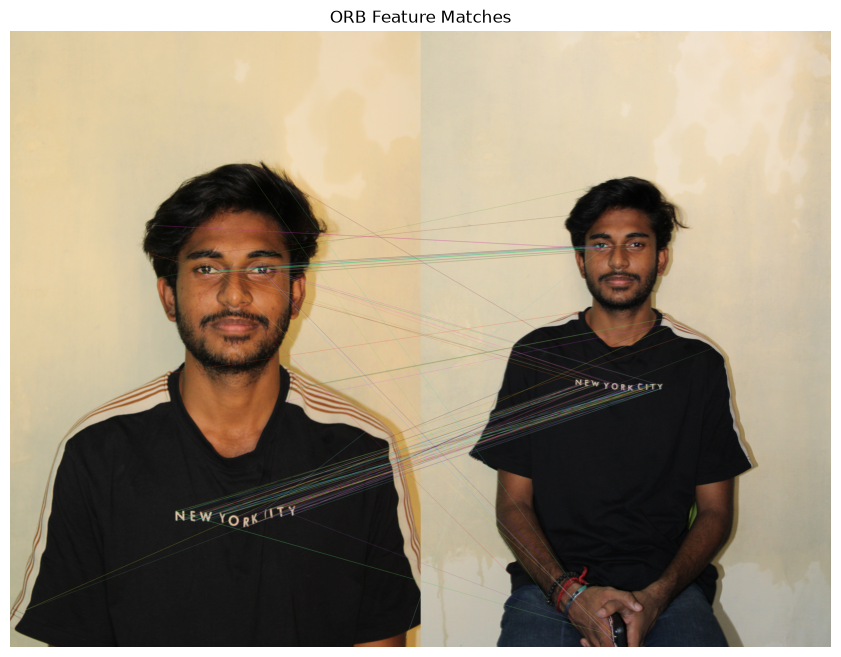

In [31]:
matched_img = cv2.drawMatches(
    img_bright,
    kp1,
    img_dark,
    kp2,
    good_matches,
    None,
    flags=2
)

plt.figure(figsize=(15,8))
plt.imshow(matched_img)
plt.title("ORB Feature Matches")
plt.axis("off")
plt.show()

In [32]:
src_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

des_pts = np.float32([kp2[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)

In [35]:
H, mask = cv2.findHomography(
    src_pts,
    des_pts,
    cv2.RANSAC,
    5.0
)

In [36]:
height, width = img1.shape[:2]

warped = cv2.warpPerspective(
    img2,
    H,
    (width, height)
)

In [ ]:

blend1 = cv2.addWeighted(
    img1,
    0.5,
    warped,
    0.5,
    0
)

blend2 = cv2.addWeighted(
    img1,
    0.7,
    warped,
    0.3,
    0
)

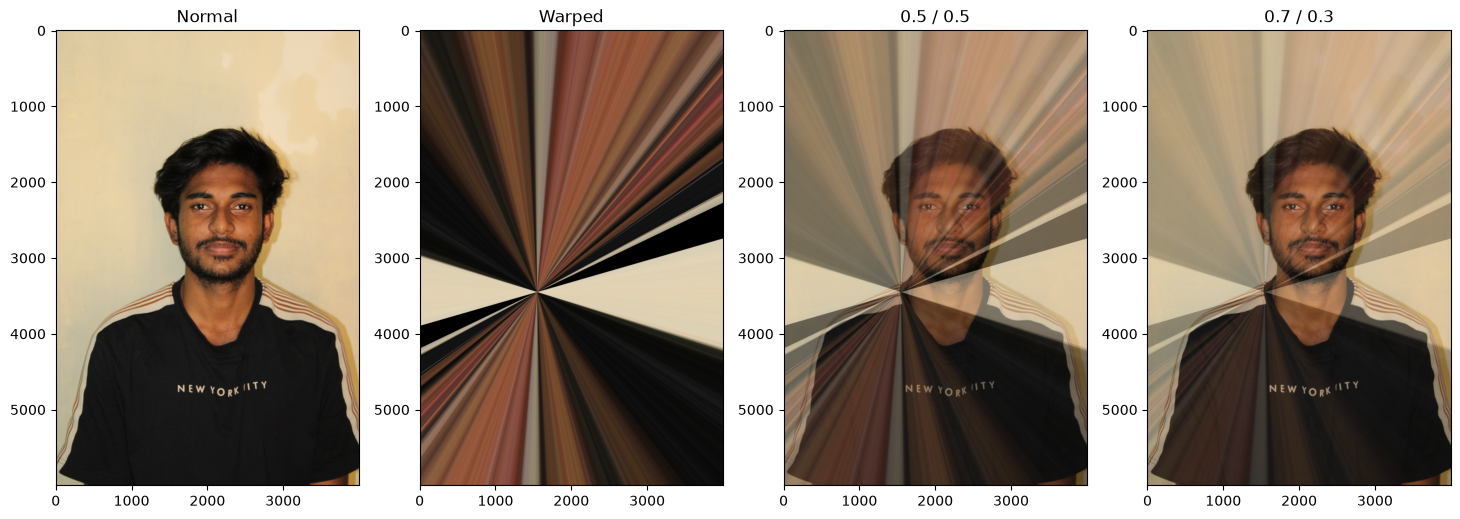

In [39]:

plt.figure(figsize=(18,6))

plt.subplot(141)
plt.imshow(cv2.cvtColor(img1,cv2.COLOR_BGR2RGB))
plt.title("Normal")

plt.subplot(142)
plt.imshow(cv2.cvtColor(warped,cv2.COLOR_BGR2RGB))
plt.title("Warped")

plt.subplot(143)
plt.imshow(cv2.cvtColor(blend1,cv2.COLOR_BGR2RGB))
plt.title("0.5 / 0.5")

plt.subplot(144)
plt.imshow(cv2.cvtColor(blend2,cv2.COLOR_BGR2RGB))
plt.title("0.7 / 0.3")

plt.show()

ORB detected sufficient feature matches to estimate a homography. However, because one image was significantly zoomed while the other captured a wider field of view, the estimated homography was inaccurate. The warped low-light image collapsed into a small region instead of aligning with the reference image, indicating that the feature correspondences were not sufficient for a stable transformation. As a result, the blended images also appeared distorted. The mismatch is likely due to the large difference in scale and field of view between the two photographs, combined with illumination differences.